# 08 — Mini overview de reseñas de Google (La Roca Pozuelo)

## Objetivo

Análisis exploratorio ligero de las reseñas públicas de Google Maps del restaurante **La Roca
Pozuelo**, como complemento cualitativo a los datos operativos (tickets, reservas, facturación) ya
analizados en el resto del proyecto.

## Origen de los datos — importante para el TFM

Google no ofrece una vía gratuita para descargar el histórico completo de reseñas de un
establecimiento:
- La API oficial de **Places** limita la respuesta a un máximo de 5 reseñas por sitio.
- Hacer *scraping* automatizado de Google Maps no es técnicamente viable con las herramientas de
  este entorno (las reseñas se renderizan con JavaScript) y además incumple los Términos de
  Servicio de Google.
- La vía gratuita y completa (**Business Profile API**) solo está disponible para el propietario
  verificado del negocio.

Por eso, los datos de este notebook proceden de una **copia manual** del listado público de reseñas
de Google Maps (`data/bronze/google_reviews_la_roca_raw.txt`), que se ha parseado a una tabla
estructurada (`data/bronze/snapshots/google_reviews_raw.parquet`). Limitaciones a tener en cuenta:

- **No hay estrellas (1-5) en los datos.** Google renderiza la puntuación como un icono gráfico, no
  como texto, así que no viaja al copiar y pegar. Todo el análisis de "positivo/negativo" que sigue
  se basa en un **lexicón de palabras** aplicado al texto, no en la puntuación real dada por Google.
- Es una **instantánea parcial**, no el histórico completo de ~1.800 reseñas que muestra la ficha
  del restaurante — es la porción que se pudo copiar manualmente del listado visible en pantalla.
- Las fechas son relativas ("hace 3 meses", "hace 2 años") tal y como las muestra Google; se han
  convertido a fechas aproximadas para poder graficarlas, con el margen de error que eso implica.

Con esas salvedades, esto sigue siendo útil como **overview cualitativo**: qué se elogia, qué se
critica, cómo responde el negocio, y si hay alguna señal temporal relevante.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
BRONZE_SNAP = DATA_DIR / 'bronze' / 'snapshots'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'reviews_overview'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures' / 'reviews_overview'
for p in (RESULTS_DIR, FIGURES_DIR):
    p.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_parquet(BRONZE_SNAP / 'google_reviews_raw.parquet')
print('Reseñas cargadas:', df.shape)
df.head(3)


Reseñas cargadas: (117, 16)


,review_id,autor,es_local_guide,n_resenas_autor,n_fotos_autor,tiempo_relativo,editado,comio_alli,turno,rango_precio,texto,texto_truncado,reacciones_total,longitud_texto,respuesta_propietario,tiempo_respuesta_propietario
0,1,Jorge Sancerni,True,171.0,745.0,Hace un mes,False,False,Cena,40-50 €,Repetiremos sin duda. Hemos ido a cenar en par...,False,1,163,NaN,NaN
1,2,Rosa Visconti,True,115.0,355.0,Hace 4 meses,False,False,Comida,40-50 €,Estaba todo realmente bueno y llegó rápido a l...,False,0,350,NaN,NaN
2,3,gonzalo martin,True,436.0,1207.0,Hace 5 meses,False,False,Cena,30-40 €,Buen restaurante en pozuelo para comer o cenar...,True,0,108,NaN,NaN


## 1. Visión general

In [2]:
print(f"Total reseñas: {len(df)}")
print(f"Autores distintos: {df['autor'].nunique()}")
print(f"Autores 'Local Guide': {df['es_local_guide'].sum()} ({df['es_local_guide'].mean()*100:.1f}%)")
print(f"Reseñas con turno indicado (Comida/Cena): {df['turno'].notna().sum()} ({df['turno'].notna().mean()*100:.1f}%)")
print(f"Reseñas con rango de precio indicado: {df['rango_precio'].notna().sum()} ({df['rango_precio'].notna().mean()*100:.1f}%)")
print(f"Reseñas con respuesta del propietario: {df['respuesta_propietario'].notna().sum()} ({df['respuesta_propietario'].notna().mean()*100:.1f}%)")
print(f"Reseñas truncadas por Google ('…Más'): {df['texto_truncado'].sum()} ({df['texto_truncado'].mean()*100:.1f}%)")
print(f"\nLongitud media del texto: {df['longitud_texto'].mean():.0f} caracteres (mediana {df['longitud_texto'].median():.0f})")


Total reseñas: 117
Autores distintos: 117
Autores 'Local Guide': 93 (79.5%)
Reseñas con turno indicado (Comida/Cena): 66 (56.4%)
Reseñas con rango de precio indicado: 65 (55.6%)
Reseñas con respuesta del propietario: 25 (21.4%)
Reseñas truncadas por Google ('…Más'): 81 (69.2%)

Longitud media del texto: 183 caracteres (mediana 176)


## 2. Turno y rango de precio declarado

Cuando el reseñador lo indica, Google muestra si fue a comer o cenar y un rango de gasto por
persona. No todos lo rellenan, así que estas distribuciones son sobre el subconjunto que sí lo hizo.

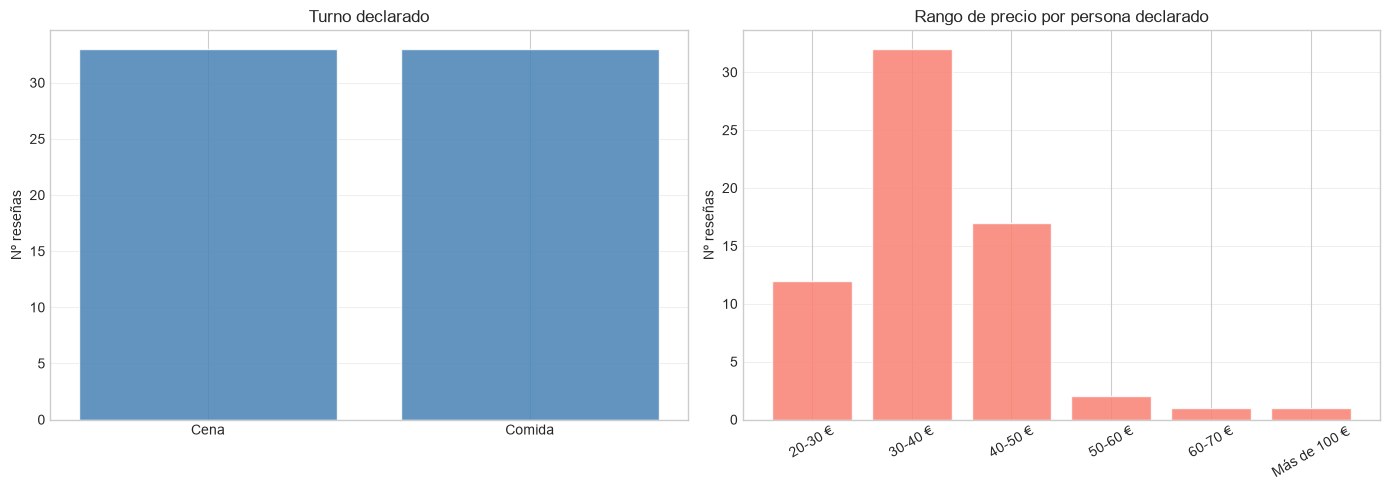

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

turno_counts = df['turno'].value_counts()
axes[0].bar(turno_counts.index, turno_counts.values, color='steelblue', alpha=0.85, edgecolor='white')
axes[0].set_title('Turno declarado')
axes[0].set_ylabel('Nº reseñas')
axes[0].grid(axis='y', alpha=0.3)

orden_precio = ['20-30 €', '30-40 €', '40-50 €', '50-60 €', '60-70 €', 'Más de 100 €']
precio_counts = df['rango_precio'].value_counts().reindex([p for p in orden_precio if p in df['rango_precio'].values])
axes[1].bar(precio_counts.index, precio_counts.values, color='salmon', alpha=0.85, edgecolor='white')
axes[1].set_title('Rango de precio por persona declarado')
axes[1].set_ylabel('Nº reseñas')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'turno_precio.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Fecha aproximada de las reseñas

Google muestra tiempo relativo ("hace 3 meses"), no fecha exacta. Se convierte a una fecha
aproximada (referencia: hoy) solo para ver la distribución temporal a grandes rasgos — no es
precisa a nivel de día.

Reseñas con fecha aproximada calculada: 116 de 117
Rango aproximado: 2018-08-23 -> 2026-07-31


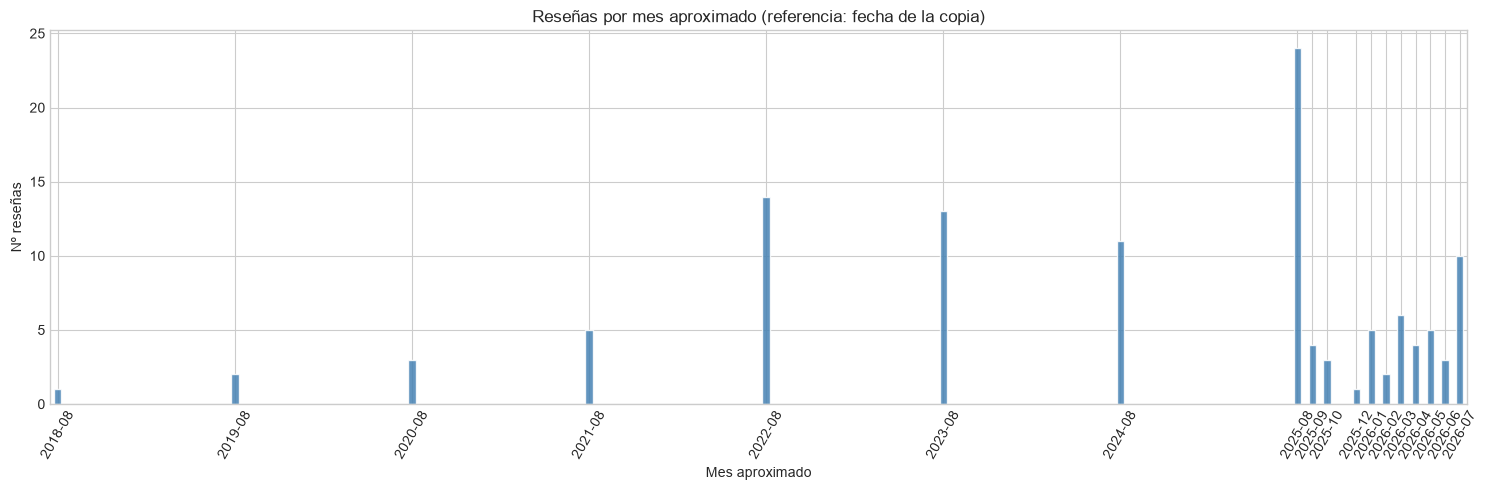

In [4]:
UNIDADES_DIAS = {
    'semana': 7, 'semanas': 7,
    'mes': 30, 'meses': 30,
    'año': 365, 'años': 365,
}
NUMEROS_TEXTO = {'un': 1, 'una': 1}

def parse_tiempo_relativo(texto):
    if not isinstance(texto, str):
        return None
    m = re.match(r'Hace (\w+) (\w+)', texto)
    if not m:
        return None
    num_txt, unidad = m.group(1), m.group(2)
    num = NUMEROS_TEXTO.get(num_txt)
    if num is None:
        try:
            num = int(num_txt)
        except ValueError:
            return None
    dias = UNIDADES_DIAS.get(unidad)
    if dias is None:
        return None
    return num * dias

HOY = pd.Timestamp.today().normalize()
df['dias_antiguedad_aprox'] = df['tiempo_relativo'].apply(parse_tiempo_relativo)
df['fecha_aprox'] = HOY - pd.to_timedelta(df['dias_antiguedad_aprox'], unit='D')
df['mes_aprox'] = df['fecha_aprox'].dt.to_period('M')

print(f"Reseñas con fecha aproximada calculada: {df['fecha_aprox'].notna().sum()} de {len(df)}")
print(f"Rango aproximado: {df['fecha_aprox'].min().date()} -> {df['fecha_aprox'].max().date()}")

por_mes = df.dropna(subset=['fecha_aprox']).groupby('mes_aprox').size()

plt.figure(figsize=(15, 5))
por_mes.plot(kind='bar', color='steelblue', alpha=0.85, edgecolor='white')
plt.title('Reseñas por mes aproximado (referencia: fecha de la copia)')
plt.ylabel('Nº reseñas')
plt.xlabel('Mes aproximado')
plt.xticks(rotation=60)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'resenas_por_mes.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Sentimiento aproximado

Sin estrellas disponibles, se aproxima el tono de cada reseña contando palabras positivas y
negativas de un lexico manual en español orientado a restauración. Es una aproximación simple
(no un modelo de NLP entrenado) pero sirve para una lectura rápida del tono general y para
priorizar qué reseñas leer con detalle.

tono
Positiva        92
Neutra/mixta    13
Negativa        12
Name: count, dtype: int64

% positivas: 78.6%
% negativas: 10.3%
% neutras/mixtas: 11.1%


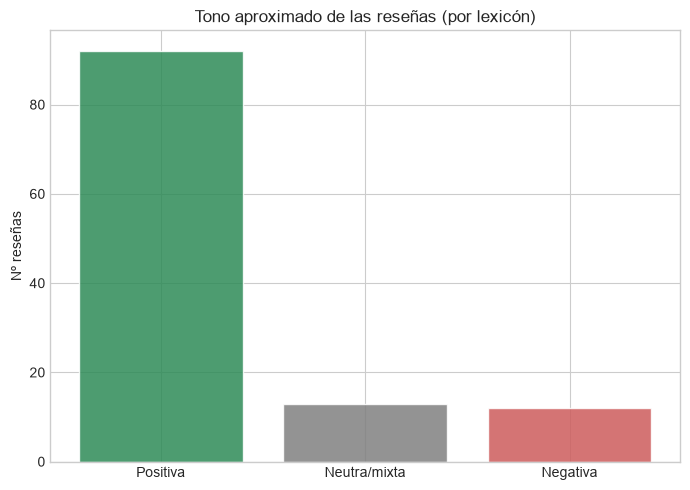

In [5]:
POSITIVAS = [
    'excelente', 'excepcional', 'espectacular', 'increible', 'increíble', 'genial', 'buenisim',
    'buenísim', 'buenaza', 'delicios', 'exquisit', 'encant', 'perfecto', 'perfecta', 'recomend',
    'volveremos', 'volveria', 'volvería', 'repetiremos', 'repetir', 'repetimos', 'maravillos',
    'fantastic', 'fantástic', 'sorprend', 'estupend', 'brutal', 'top', 'impecable', 'agradable',
    'atento', 'atenta', 'amable', 'profesional', 'rico', 'rica', 'ricos', 'ricas', 'gustó', 'gusto',
    'imprescindible', 'acierto', 'calidad', 'cuidad',
]
NEGATIVAS = [
    'mal', 'malo', 'mala', 'malos', 'peor', 'decepcion', 'decepcion', 'decepcionante', 'escas',
    'pequeñ', 'caro', 'cara', 'caros', 'salad', 'duro', 'dura', 'pesim', 'pésim', 'nada recomendable',
    'no repetir', 'no repetiría', 'no volveria', 'no volvería', 'lento', 'lenta', 'espera',
    'desastr', 'sucio', 'sucia', 'irrisori', 'olvidable', 'flojo', 'floja', 'no acertamos',
]

def contar_lexicon(texto, lexicon):
    if not isinstance(texto, str):
        return 0
    texto_low = texto.lower()
    return sum(texto_low.count(palabra) for palabra in lexicon)

df['score_positivo'] = df['texto'].apply(lambda t: contar_lexicon(t, POSITIVAS))
df['score_negativo'] = df['texto'].apply(lambda t: contar_lexicon(t, NEGATIVAS))
df['score_sentimiento'] = df['score_positivo'] - df['score_negativo']

def clasificar(score):
    if score > 0:
        return 'Positiva'
    if score < 0:
        return 'Negativa'
    return 'Neutra/mixta'

df['tono'] = df['score_sentimiento'].apply(clasificar)

tono_counts = df['tono'].value_counts()
print(tono_counts)
print(f"\n% positivas: {(df['tono']=='Positiva').mean()*100:.1f}%")
print(f"% negativas: {(df['tono']=='Negativa').mean()*100:.1f}%")
print(f"% neutras/mixtas: {(df['tono']=='Neutra/mixta').mean()*100:.1f}%")

plt.figure(figsize=(7, 5))
colors = {'Positiva': 'seagreen', 'Negativa': 'indianred', 'Neutra/mixta': 'grey'}
plt.bar(tono_counts.index, tono_counts.values, color=[colors[t] for t in tono_counts.index], alpha=0.85, edgecolor='white')
plt.title('Tono aproximado de las reseñas (por lexicón)')
plt.ylabel('Nº reseñas')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'tono_resenas.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. ¿Responde el negocio más a las reseñas negativas?

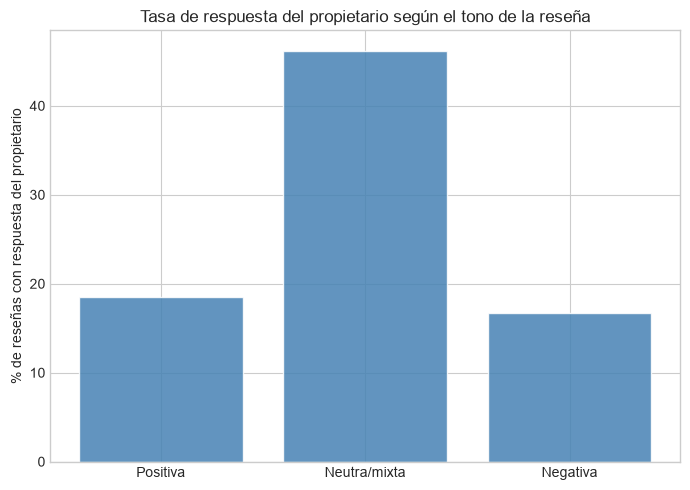

,% con respuesta
tono,
Positiva,18.5
Neutra/mixta,46.2
Negativa,16.7


In [6]:
respuesta_por_tono = (
    df.groupby('tono')['respuesta_propietario']
    .apply(lambda s: s.notna().mean() * 100)
    .reindex(['Positiva', 'Neutra/mixta', 'Negativa'])
)

plt.figure(figsize=(7, 5))
plt.bar(respuesta_por_tono.index, respuesta_por_tono.values, color='steelblue', alpha=0.85, edgecolor='white')
plt.ylabel('% de reseñas con respuesta del propietario')
plt.title('Tasa de respuesta del propietario según el tono de la reseña')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'respuesta_por_tono.png', dpi=150, bbox_inches='tight')
plt.show()

display(respuesta_por_tono.round(1).to_frame('% con respuesta'))


## 6. Palabras y platos más mencionados

Frecuencia de palabras (excluyendo palabras vacías) y de una lista curada de platos que aparecen
repetidamente en las reseñas leídas.

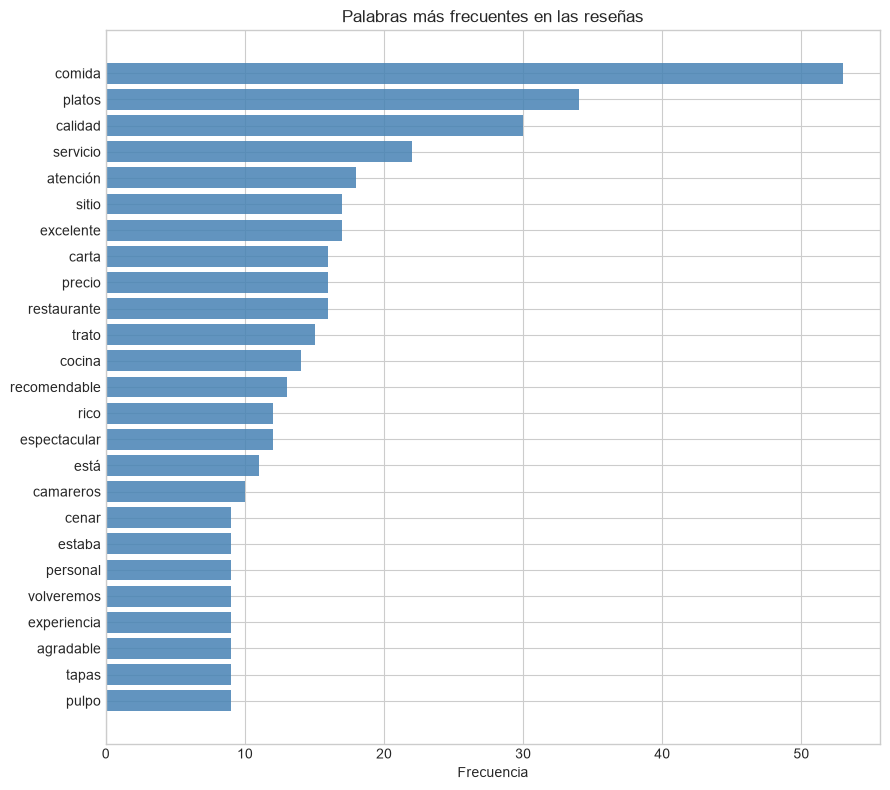

,plato,menciones
0,tarta,13
1,tartar,9
2,pulpo,9
3,bao,9
4,croquetas,8
5,torrija,7
6,ravioli,6
7,bombones de foie,6
8,bravas,6
9,gambas,6


In [7]:
STOPWORDS_TXT = (
    'de la el en y a que los las un una con muy por para no se su es lo todo todos mas más pero nos del al '
    'como fue ha han esta este eso ese esa mi mis tu tus si sí o u e nuestro nuestra nos nuestros '
    'te le les da dan das doy vamos van fui fuimos era eran estan están estuvo estuvimos tambien también '
    'que qué cual cuales donde dónde cuando cuándo porque bien buen buena buenas buenos poco pocos'
)
STOPWORDS = set(STOPWORDS_TXT.split())

def tokenizar(texto):
    if not isinstance(texto, str):
        return []
    palabras = re.findall(r"[a-záéíóúñü]+", texto.lower())
    return [p for p in palabras if len(p) > 3 and p not in STOPWORDS]

todas_palabras = [w for t in df['texto'] for w in tokenizar(t)]
top_palabras = Counter(todas_palabras).most_common(25)
top_palabras_df = pd.DataFrame(top_palabras, columns=['palabra', 'frecuencia'])

plt.figure(figsize=(9, 8))
plot_df = top_palabras_df.sort_values('frecuencia')
plt.barh(plot_df['palabra'], plot_df['frecuencia'], color='steelblue', alpha=0.85)
plt.xlabel('Frecuencia')
plt.title('Palabras más frecuentes en las reseñas')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'palabras_frecuentes.png', dpi=150, bbox_inches='tight')
plt.show()

PLATOS = [
    'tartar', 'croquetas', 'torreznos', 'ravioli', 'bombones de foie', 'pulpo', 'bao',
    'bravas', 'tortilla', 'zamburiñas', 'carpaccio', 'torrija', 'tarta', 'chuletillas',
    'mejillones', 'solomillo', 'callos', 'ensaladilla', 'arroz', 'alcachofas', 'gambas',
    'canelón', 'wagyu', 'oreja', 'cochinita', 'empanadilla',
]

def contar_plato(texto, plato):
    if not isinstance(texto, str):
        return 0
    return texto.lower().count(plato)

conteo_platos = {plato: df['texto'].apply(lambda t: contar_plato(t, plato)).sum() for plato in PLATOS}
platos_df = pd.DataFrame(sorted(conteo_platos.items(), key=lambda x: -x[1]), columns=['plato', 'menciones'])
platos_df = platos_df[platos_df['menciones'] > 0]

display(platos_df)


## 7. Las reseñas más positivas y más negativas (lectura cualitativa)

In [8]:
print('=== TOP 8 más positivas ===')
for _, row in df.sort_values('score_sentimiento', ascending=False).head(8).iterrows():
    print(f"- ({row['autor']}, {row['tiempo_relativo']}, score {row['score_sentimiento']}): {row['texto'][:200]}")

print('\n=== TOP 8 más negativas ===')
for _, row in df.sort_values('score_sentimiento', ascending=True).head(8).iterrows():
    print(f"- ({row['autor']}, {row['tiempo_relativo']}, score {row['score_sentimiento']}): {row['texto'][:200]}")


=== TOP 8 más positivas ===
- (Aránzazu, Hace 2 años, score 7): Me gustó, fui con mi marido ayer para cenar. Atienden rápido y muy bien, la comida muy buena, no son tapas de gran tamaño pero nos gustó probarlas. Los camareros son muy agradables. Repetiremos seguro
- (Gonzalo Gomez, Hace 6 años, score 6): Un sitio cojonudo. Camareros majos y muy agradables. La comida increible. La tortilla de Betanzos como si la hubiera comido en Galicia. Las croquetas divinas. El pulpo rico, rico, rico. Así da gusto. 
- (Mamen GoAl, Hace un año, score 6): Sitio que merece la pena conocer. Comida muy rica, camareros agradables y profesionales, relación calidad precio excelente. Recomendable 100%.
- (Delfina Kg, Hace 4 años, score 6): Sitio excelente y Comida de gran calidad. El trato es excelente, sus camareros son muy amables y encantadores. Óscar siempre nos guía con buenas recomendaciones sobre los platos de la carta. Platos co
- (Elena Liz Barrenechea, Hace un año, score 6): Sitio original con comid

## 8. Guardar resultados

Se guarda la tabla enriquecida (con fecha aproximada y tono estimado) junto al resto de resultados
del proyecto. Se mantiene en `data/bronze` porque, a diferencia del resto de fuentes del proyecto,
esta no ha pasado por un proceso formal de depuración Silver — es una instantánea manual parcial,
no una fuente reproducible desde el pipeline bronze→silver→gold habitual.

In [9]:
cols_guardar = [
    'review_id', 'autor', 'es_local_guide', 'n_resenas_autor', 'n_fotos_autor',
    'tiempo_relativo', 'fecha_aprox', 'editado', 'comio_alli', 'turno', 'rango_precio',
    'texto', 'texto_truncado', 'longitud_texto', 'reacciones_total',
    'score_positivo', 'score_negativo', 'score_sentimiento', 'tono',
    'respuesta_propietario', 'tiempo_respuesta_propietario',
]
df_out = df[cols_guardar]

df_out.to_parquet(BRONZE_SNAP / 'google_reviews_enriched.parquet', index=False)
df_out.to_csv(RESULTS_DIR / 'google_reviews_overview.csv', index=False, encoding='utf-8-sig')
top_palabras_df.to_csv(RESULTS_DIR / 'palabras_frecuentes.csv', index=False, encoding='utf-8-sig')
platos_df.to_csv(RESULTS_DIR / 'platos_mencionados.csv', index=False, encoding='utf-8-sig')

print('Guardado en:')
print(' -', BRONZE_SNAP / 'google_reviews_enriched.parquet')
print(' -', RESULTS_DIR / 'google_reviews_overview.csv')


Guardado en:
 - C:\Users\CandelaGB\Desktop\TFM anita\TFM-Hosteleria-AI\data\bronze\snapshots\google_reviews_enriched.parquet
 - C:\Users\CandelaGB\Desktop\TFM anita\TFM-Hosteleria-AI\results\reviews_overview\google_reviews_overview.csv


## 9. Conclusión del mini overview

In [10]:
print('=' * 72)
print('MINI OVERVIEW — RESEÑAS GOOGLE LA ROCA POZUELO')
print('=' * 72)
print(f"Reseñas analizadas: {len(df)} (muestra parcial copiada manualmente, no el histórico completo)")
print(f"Tono positivo: {(df['tono']=='Positiva').mean()*100:.1f}%  |  "
      f"negativo: {(df['tono']=='Negativa').mean()*100:.1f}%  |  "
      f"neutro/mixto: {(df['tono']=='Neutra/mixta').mean()*100:.1f}%")
print(f"Tasa de respuesta del propietario: {df['respuesta_propietario'].notna().mean()*100:.1f}%")
print(f"Plato más mencionado: {platos_df.iloc[0]['plato']} ({int(platos_df.iloc[0]['menciones'])} menciones)"
      if len(platos_df) else "Sin datos suficientes de platos.")

print('\nLimitaciones:')
print('- No hay estrellas reales: el tono es una estimación por palabras clave, no la puntuación de Google.')
print('- Es una muestra parcial de la copia manual, no las ~1.800 reseñas totales del restaurante.')
print('- Las fechas son aproximadas a partir de expresiones relativas ("hace X meses").')
print('- Para un análisis definitivo de reseñas, la vía recomendada sigue siendo la Business Profile')
print('  API si el restaurante tiene acceso como propietario verificado.')


MINI OVERVIEW — RESEÑAS GOOGLE LA ROCA POZUELO
Reseñas analizadas: 117 (muestra parcial copiada manualmente, no el histórico completo)
Tono positivo: 78.6%  |  negativo: 10.3%  |  neutro/mixto: 11.1%
Tasa de respuesta del propietario: 21.4%
Plato más mencionado: tarta (13 menciones)

Limitaciones:
- No hay estrellas reales: el tono es una estimación por palabras clave, no la puntuación de Google.
- Es una muestra parcial de la copia manual, no las ~1.800 reseñas totales del restaurante.
- Las fechas son aproximadas a partir de expresiones relativas ("hace X meses").
- Para un análisis definitivo de reseñas, la vía recomendada sigue siendo la Business Profile
  API si el restaurante tiene acceso como propietario verificado.
